# Unemployment Analysis in India
### CodeAlpha Data Science Internship — Task 2

Analyze unemployment trends, the COVID-19 period, and regional differences.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load and clean the dataset

In [2]:
df = pd.read_csv("Unemployment in India.csv")
df.columns = [column.strip() for column in df.columns]
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Shape:", df.shape)
display(df.head())
print("\nMissing values:")
display(df.isnull().sum())

Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural



Missing values:


Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

## 2. Overall unemployment trend

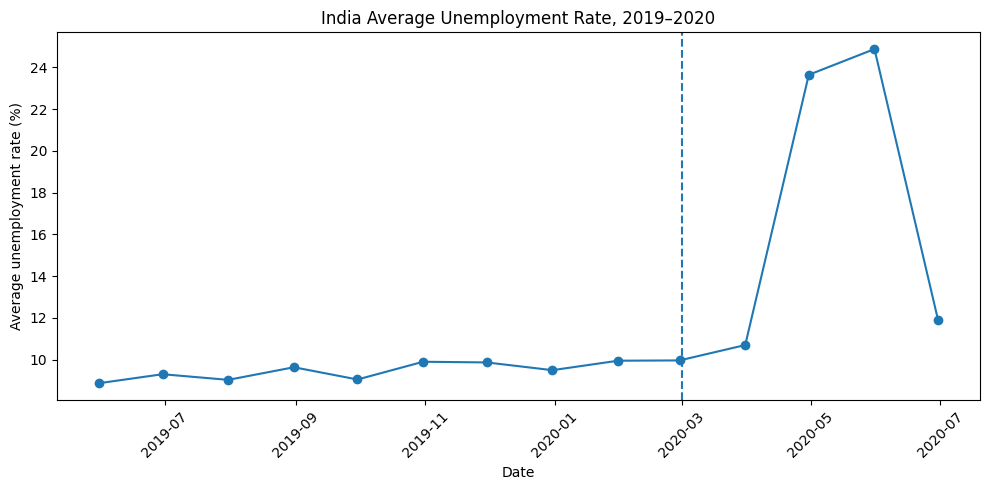

In [3]:
monthly = df.groupby("Date", as_index=False)["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly["Date"], monthly["Estimated Unemployment Rate (%)"], marker="o")
plt.axvline(pd.Timestamp("2020-03-01"), linestyle="--")
plt.xlabel("Date")
plt.ylabel("Average unemployment rate (%)")
plt.title("India Average Unemployment Rate, 2019–2020")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The monthly average remained around the 9–10% range through most of 2019 and early 2020. It then increased sharply in April and May 2020. The highest monthly average was **24.88% in May 2020**.

## 3. COVID-19 period comparison

In [4]:
before_covid = df[df["Date"] < "2020-03-01"]["Estimated Unemployment Rate (%)"].mean()
march_2020 = df[df["Date"].dt.to_period("M") == "2020-03"]["Estimated Unemployment Rate (%)"].mean()
april_may = df[df["Date"].between("2020-04-01", "2020-05-31")]["Estimated Unemployment Rate (%)"].mean()
june_2020 = df[df["Date"].dt.to_period("M") == "2020-06"]["Estimated Unemployment Rate (%)"].mean()

print(f"Before COVID period: {before_covid:.2f}%")
print(f"March 2020: {march_2020:.2f}%")
print(f"April–May 2020: {april_may:.2f}%")
print(f"June 2020: {june_2020:.2f}%")

Before COVID period: 9.51%
March 2020: 10.70%
April–May 2020: 24.26%
June 2020: 11.90%


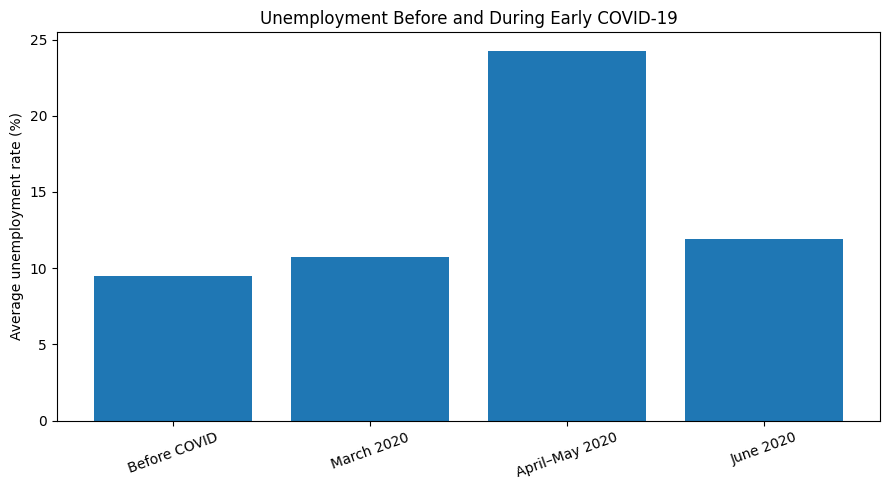

In [5]:
comparison = pd.DataFrame({
    "Period": ["Before COVID", "March 2020", "April–May 2020", "June 2020"],
    "Average unemployment rate (%)": [before_covid, march_2020, april_may, june_2020]
})

plt.figure(figsize=(9, 5))
plt.bar(comparison["Period"], comparison["Average unemployment rate (%)"])
plt.ylabel("Average unemployment rate (%)")
plt.title("Unemployment Before and During Early COVID-19")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The increase during April and May 2020 is the most prominent change in the dataset. The decline in June indicates that the spike was followed by a substantial short-term reduction.

## 4. Regional comparison

,Average unemployment rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


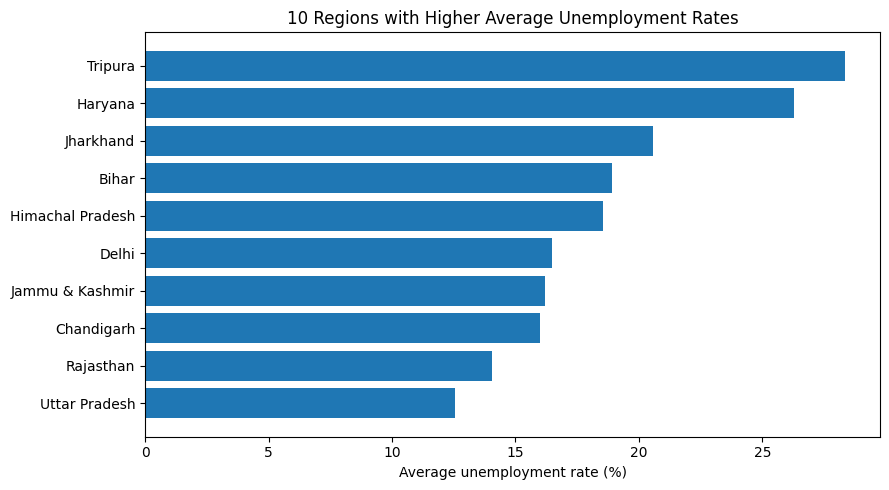

In [6]:
regional = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

display(regional.to_frame("Average unemployment rate (%)"))

plt.figure(figsize=(9, 5))
plt.barh(regional.index[::-1], regional.values[::-1])
plt.xlabel("Average unemployment rate (%)")
plt.title("10 Regions with Higher Average Unemployment Rates")
plt.tight_layout()
plt.show()

## 5. Conclusion

The data shows relatively stable unemployment levels through much of 2019, followed by a sharp increase in early 2020 and a particularly large spike in April and May. June 2020 shows a substantial decline from the peak. Because the dataset covers only about 14 months, it is not long enough to establish a reliable recurring seasonal pattern or a long-term trend over multiple years.